01_business_roi_statistical_validation.ipynb

03_sql_pyspark_summary_packaging.ipynb

# Notebook 02 – Predictive Modeling, Targeting, and Campaign Optimization

## Project Continuation Context

This notebook continues the Campaign Prophet project from Notebook 01: Business Understanding, ROI Analysis, and Statistical Validation.

Notebook 01 established the analytical foundation by:
- Loading and validating the UCI Bank Marketing dataset
- Removing duplicate records and preparing the cleaned dataset
- Creating business-friendly engineered features
- Developing USD and EUR / CLV-based ROI frameworks
- Calculating segment-level profitability and expected value
- Performing statistical hypothesis testing on key customer and campaign variables

This notebook builds on those validated outputs to develop predictive models, score customers, optimize campaign targeting, and generate decision-ready campaign insights.

---
## Objective

Build and evaluate predictive models to estimate customer subscription likelihood, use model outputs for ROI-based targeting, and create campaign optimization insights that support data-driven marketing decisions.

This notebook moves the project from descriptive and statistical analysis into predictive and prescriptive analytics.

---
## What to Expect in This Notebook

This notebook represents the second part of the Campaign Prophet project. It focuses on predictive modeling, customer scoring, campaign targeting, ROI optimization, and visual campaign insights.

The notebook uses the cleaned and feature-engineered dataset saved from Notebook 01. It does not repeat data loading, exploratory analysis, ROI assumption development, or statistical hypothesis testing.

The main workflow includes:
- Loading validated outputs from Notebook 01
- Defining modeling strategies for full and pre-contact prediction
- Preparing features for machine learning
- Training and evaluating classification models
- Comparing Logistic Regression, Random Forest, and XGBoost
- Selecting an operational model for customer targeting
- Scoring customers by predicted subscription probability
- Translating model scores into expected value and ROI decisions
- Creating campaign insight visualizations

By the end of this notebook, we will identify which customers should be prioritized for outreach and how model-driven targeting can improve campaign efficiency.

---
## Phase-Wise Execution Plan

This notebook covers the predictive and optimization stages of the Campaign Prophet project.

| Phase | Description |
|---|---|
| Phase 4 – Predictive Modeling | Build and compare classification models to estimate customer subscription likelihood. |
| Phase 5 – ROI Optimization and Customer Segmentation | Use predicted probabilities to score customers, calculate expected value, and optimize targeting decisions. |
| Phase 6 – Visualizations and Campaign Insights | Create visual summaries of model performance, customer segments, and campaign optimization results. |

---
## Notebook Input Dependencies

This notebook depends on the following outputs saved from Notebook 01:

| Input Artifact | Purpose |
|---|---|
| `cleaned_feature_engineered_bank_marketing.csv` | Cleaned dataset with engineered features from Phases 1–3 |
| `job_summary.csv` | Segment-level campaign performance by job category |
| `expected_value_usd_base.csv` | USD Base Case expected value output |
| `expected_value_eur_base.csv` | EUR Base Case expected value output |
| `usd_eur_ranking_comparison.csv` | Cross-framework ROI ranking comparison |
| `job_subscription_summary.csv` | Job-level subscription summary from Phase 3.1 |
| `poutcome_subscription_summary.csv` | Previous campaign outcome summary from Phase 3.2 |
| `duration_summary.csv` | Call duration summary from Phase 3.3 |
| `age_summary.csv` | Age summary from Phase 3.4 |
| `roi_scenarios_usd.pkl` | USD ROI scenario assumptions |
| `breakeven_rates_usd.pkl` | USD breakeven thresholds |
| `roi_scenarios_eur.pkl` | EUR / CLV scenario assumptions |
| `breakeven_rates_eur.pkl` | EUR breakeven thresholds |
---
## Business Questions to Be Addressed in This Notebook

| MQ/CQ ID | Business Question | Planned Phase | Status Before Notebook |
|---|---|---|---|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Phase 4 | Pending |
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Phase 4 | Pending |
| MQ15 / CQ3 | Which macroeconomic indicators most strongly influence conversion? | Phase 4 | Pending |
| MQ16 / CQ12 | Which operational factors should guide campaign planning? | Phase 4 / Phase 5 | Pending |
| MQ17 | Which customers should be prioritized before contact? | Phase 5 | Pending |
| MQ18 / CQ13 | Which variables are unavailable before contact and therefore unsuitable for proactive targeting? | Phase 4 | Pending |
| MQ21 | Which predictive model should be selected for deployment? | Phase 4 | Pending |
| MQ22 | How much predictive lift is gained by advanced models compared with Logistic Regression? | Phase 4 | Pending |
| MQ23 | What is the best operational model for ROI optimization and customer targeting? | Phase 4 / Phase 5 | Pending |
| CQ15 | Which probability segments deliver the highest ROI? | Phase 5 | Pending |
| CQ16 | How should marketing budgets be allocated to maximize profitability? | Phase 5 | Pending |
| CQ17 | What is the optimal probability threshold for customer targeting? | Phase 5 | Pending |
| CQ18 | What percentage of customers should be contacted to maximize ROI? | Phase 5 | Pending |
| CQ19 | How much predictive lift is gained by including post-contact variables such as call duration? | Phase 4 | Pending |

---
# Environment Set-up:

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# File handling and object serialization
import os
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine Learning preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model selection
from sklearn.model_selection import train_test_split
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Model evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Miscellaneous
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Notebook 02 environment setup complete.")

Notebook 02 environment setup complete.


In [ ]:
# mounting drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Check Notebook 01 output folder

input_dir = "/content/drive/MyDrive/Campaign_Prophet/outputs/notebook_01"

print("Folder exists:", os.path.exists(input_dir))

print("\nFiles found:")
for file in os.listdir(input_dir):
    print("-", file)

Folder exists: True

Files found:
- duration_summary.csv
- poutcome_subscription_summary.csv
- expected_value_usd_base.csv
- job_subscription_summary.csv
- roi_scenarios_usd.pkl
- age_summary.csv
- usd_eur_ranking_comparison.csv
- expected_value_eur_base.csv
- job_summary.csv
- cleaned_feature_engineered_bank_marketing.csv
- breakeven_rates_usd.pkl
- breakeven_rates_eur.pkl
- roi_scenarios_eur.pkl


In [ ]:
# Load Notebook 01 outputs

input_dir = "/content/drive/MyDrive/Campaign_Prophet/outputs/notebook_01"

df = pd.read_csv(f"{input_dir}/cleaned_feature_engineered_bank_marketing.csv")

job_summary = pd.read_csv(f"{input_dir}/job_summary.csv")
ev_analysis = pd.read_csv(f"{input_dir}/expected_value_usd_base.csv")
eur_ev = pd.read_csv(f"{input_dir}/expected_value_eur_base.csv")
ranking_comparison = pd.read_csv(f"{input_dir}/usd_eur_ranking_comparison.csv")

job_subscription_summary = pd.read_csv(f"{input_dir}/job_subscription_summary.csv")
poutcome_subscription_summary = pd.read_csv(f"{input_dir}/poutcome_subscription_summary.csv")
duration_summary = pd.read_csv(f"{input_dir}/duration_summary.csv")
age_summary = pd.read_csv(f"{input_dir}/age_summary.csv")

with open(f"{input_dir}/roi_scenarios_usd.pkl", "rb") as f:
    roi_scenarios = pickle.load(f)

with open(f"{input_dir}/breakeven_rates_usd.pkl", "rb") as f:
    breakeven_rates = pickle.load(f)

with open(f"{input_dir}/roi_scenarios_eur.pkl", "rb") as f:
    eur_scenarios = pickle.load(f)

with open(f"{input_dir}/breakeven_rates_eur.pkl", "rb") as f:
    eur_breakeven_rates = pickle.load(f)

print("Notebook 01 outputs loaded successfully.")
print("Dataset shape:", df.shape)

Notebook 01 outputs loaded successfully.
Dataset shape: (41176, 25)


In [ ]:
# Validate loaded inputs from Notebook 01

print("Loaded Dataset Shape:", df.shape)

print("\nTarget Distribution:")
print(df['y'].value_counts())

print("\nEngineered Columns Check:")
required_columns = ['success', 'age_group', 'duration_category', 'had_previous_contact']

for col in required_columns:
    print(f"{col}: {'Found' if col in df.columns else 'Missing'}")

print("\nSaved Summary Tables:")
summary_tables = {
    "job_summary": job_summary,
    "ev_analysis": ev_analysis,
    "eur_ev": eur_ev,
    "ranking_comparison": ranking_comparison,
    "job_subscription_summary": job_subscription_summary,
    "poutcome_subscription_summary": poutcome_subscription_summary,
    "duration_summary": duration_summary,
    "age_summary": age_summary
}

for name, table in summary_tables.items():
    print(f"{name}: {table.shape}")

Loaded Dataset Shape: (41176, 25)

Target Distribution:
y
no     36537
yes     4639
Name: count, dtype: int64

Engineered Columns Check:
success: Found
age_group: Found
duration_category: Found
had_previous_contact: Found

Saved Summary Tables:
job_summary: (12, 6)
ev_analysis: (12, 9)
eur_ev: (12, 8)
ranking_comparison: (12, 4)
job_subscription_summary: (12, 5)
poutcome_subscription_summary: (3, 5)
duration_summary: (2, 5)
age_summary: (2, 5)


## Phase 4 – Predictive Modeling

### Objective

Build machine learning models to predict which customers are most likely to subscribe to the term deposit product and identify the most influential predictors of customer response.

### Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Phase |
|--------|----------------|----------------|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Pending |
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Pending |
| MQ15 / CQ3 | Which macroeconomic indicators most strongly influence conversion? | Pending |
| MQ16 / CQ12 | Which operational factors should guide campaign planning? | Pending |
| MQ18 / CQ13 | Which variables are unavailable before contact and therefore unsuitable for proactive targeting? | Pending |
| CQ14 | Which features are actionable before contacting the customer? | Pending |
| CQ19 | How much predictive lift is gained by including post-contact variables such as call duration? | Pending |
| MQ21 | Which predictive model should be selected for deployment? | Pending |
| MQ22 | How much predictive lift is gained by advanced models compared with Logistic Regression? | Pending |

### What to Expect in This Phase

This phase develops predictive models using Logistic Regression, Random Forest, and XGBoost to estimate customer subscription probability and identify the strongest drivers of conversion.

### Analytical Focus

- Select modeling features
- Build full and pre-contact models
- Train multiple machine learning algorithms
- Compare predictive performance
- Interpret feature importance
- Distinguish actionable features from operationally limited variables

### Expected Business Outcome

By the end of this phase, we will know how accurately customer response can be predicted, which variables matter most, and which model should be carried forward for ROI-based targeting in Phase 5.

### Subsections

- 4.1 Feature Selection and Modeling Strategy
- 4.2 Data Preprocessing for Machine Learning
- 4.3 Logistic Regression Modeling
- 4.4 Random Forest Modeling
- 4.5 XGBoost Modeling
- 4.6 Cross-Model Comparison and Final Model Selection
- 4.7 Questions Answered in Phase 4

## 4.1 Feature Selection and Modeling Strategy

### Objective

Define which variables will be used for predictive modeling and distinguish between features available before customer contact and features known only after contact begins.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Pending |
| MQ18 / CQ13 | Which variables are unavailable before contact and therefore unsuitable for proactive targeting? | Pending |
| CQ14 | Which features are actionable before contacting the customer? | Pending |
| CQ19 | How much predictive lift is gained by including post-contact variables such as call duration? | Pending |

### What to Expect in This Section

This section defines two modeling strategies:

1. **Full Model** – includes all available predictors, including post-contact variables such as call duration.
2. **Pre-Contact Model** – excludes variables unavailable before contacting the customer.

### Analytical Focus

- Identify candidate predictors
- Separate pre-contact and post-contact variables
- Document modeling assumptions
- Establish the feature sets used for predictive modeling

### Expected Business Outcome

By the end of this section, we will establish a modeling strategy that supports both maximum predictive performance and realistic operational targeting.

In [ ]:
# 4.1 Feature Selection and Modeling Strategy

# Define columns not to use as predictors
excluded_columns = [
    'y',
    'success',
    'age_group',
    'duration_category'
]

# Full Model features
full_features = [
    col for col in df.columns
    if col not in excluded_columns
]

# Pre-Contact Model features
pre_contact_exclusions = excluded_columns + [
    'duration',   # known only after the call begins
    'campaign'    # depends on current campaign interaction attempts
]

pre_contact_features = [
    col for col in df.columns
    if col not in pre_contact_exclusions
]

# Features excluded from Pre-Contact Model
post_contact_or_operationally_limited_features = sorted(
    set(full_features) - set(pre_contact_features)
)

print("Feature sets created successfully.")
print(f"Full Model Feature Count: {len(full_features)}")
print(f"Pre-Contact Model Feature Count: {len(pre_contact_features)}")

Feature sets created successfully.
Full Model Feature Count: 21
Pre-Contact Model Feature Count: 19


In [ ]:
# 4.1 Feature Strategy Validation

print("Features included in Full Model but excluded from Pre-Contact Model:")
for feature in post_contact_or_operationally_limited_features:
    print("-", feature)

print("\nFull Model Features:")
for feature in full_features:
    print("-", feature)

print("\nPre-Contact Model Features:")
for feature in pre_contact_features:
    print("-", feature)

print("\nValidation Checks")
print("-" * 70)
print("Target variable excluded from Full Model:", 'success' not in full_features)
print("Target variable excluded from Pre-Contact Model:", 'success' not in pre_contact_features)
print("Raw outcome column excluded from Full Model:", 'y' not in full_features)
print("Raw outcome column excluded from Pre-Contact Model:", 'y' not in pre_contact_features)
print("Duration excluded from Pre-Contact Model:", 'duration' not in pre_contact_features)
print("Campaign excluded from Pre-Contact Model:", 'campaign' not in pre_contact_features)

Features included in Full Model but excluded from Pre-Contact Model:
- campaign
- duration

Full Model Features:
- age
- job
- marital
- education
- default
- housing
- loan
- contact
- month
- day_of_week
- duration
- campaign
- pdays
- previous
- poutcome
- emp.var.rate
- cons.price.idx
- cons.conf.idx
- euribor3m
- nr.employed
- had_previous_contact

Pre-Contact Model Features:
- age
- job
- marital
- education
- default
- housing
- loan
- contact
- month
- day_of_week
- pdays
- previous
- poutcome
- emp.var.rate
- cons.price.idx
- cons.conf.idx
- euribor3m
- nr.employed
- had_previous_contact

Validation Checks
----------------------------------------------------------------------
Target variable excluded from Full Model: True
Target variable excluded from Pre-Contact Model: True
Raw outcome column excluded from Full Model: True
Raw outcome column excluded from Pre-Contact Model: True
Duration excluded from Pre-Contact Model: True
Campaign excluded from Pre-Contact Model: True


#### Inference-13 from Feature Selection and Modeling Strategy

Two complementary modeling strategies were established to balance predictive performance and real-world operational usability.

**Key Findings**
- The **Full Model** includes 21 predictors and incorporates post-contact or campaign-interaction variables such as `duration` and `campaign`.
- The **Pre-Contact Model** includes 19 predictors and excludes variables that are unavailable or not reliable before initiating customer contact.
- The variables excluded from the Pre-Contact Model are:
  - `duration`
  - `campaign`
- Target-related columns such as `y` and `success` were excluded from both feature sets to avoid target leakage.
- The Pre-Contact Model retains demographic, customer history, campaign timing, contact channel, and macroeconomic variables that are available before outreach.

**Operational Classification**
- **Actionable Before Contact:** age, job, marital status, education, default status, housing loan, personal loan, contact method, campaign month, day of week, prior campaign history, and macroeconomic indicators.
- **Operationally Limited:** `duration` and `campaign`, because they depend on the current outreach interaction.

**Overall Conclusion**

The project will develop both a Full Model and a Pre-Contact Model to compare maximum predictive performance against operational feasibility. The Full Model is useful for understanding total predictive signal, while the Pre-Contact Model is more suitable for real-world customer targeting because it uses only variables available before outreach.

---
## Questions Answered in Phase 4.1 – Feature Selection and Modeling Strategy

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ18 / CQ13 | `duration` and `campaign` were identified as operationally limited variables and excluded from the Pre-Contact Model. | Completed |
| CQ14 | Nineteen pre-contact features were identified, including demographic, historical, contact-channel, campaign-timing, and macroeconomic variables that can support proactive targeting. | Completed |
| CQ19 | The Full Model includes `duration` and `campaign`, while the Pre-Contact Model excludes them, allowing later comparison of predictive lift from post-contact variables. | Partially Completed |

## 4.2 Data Preprocessing for Machine Learning

### Objective

Prepare the selected predictors for machine learning by encoding categorical variables and splitting the dataset into training and testing sets.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Pending |
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Pending |
| MQ18 / CQ13 | Which variables are unavailable before contact and therefore unsuitable for proactive targeting? | Partially Completed |

### What to Expect in This Section

This section converts categorical variables into numerical format and creates consistent train/test datasets for both the Full Model and the Pre-Contact Model.

### Analytical Focus

- Separate predictors and target variable
- One-hot encode categorical variables
- Create Full Model and Pre-Contact Model datasets
- Use stratified train/test splitting to preserve class proportions
- Validate training and testing dataset shapes

### Expected Business Outcome

By the end of this section, we will have machine-learning-ready datasets for all modeling algorithms while preserving a clear distinction between explanatory full-model analysis and operational pre-contact targeting.

In [ ]:
# 4.2 Data Preprocessing for Machine Learning - Feature Encoding

# Define target variable
y = df['success']

# Prepare Full Model dataset
X_full = pd.get_dummies(
    df[full_features],
    drop_first=True
)

# Prepare Pre-Contact Model dataset
X_pre = pd.get_dummies(
    df[pre_contact_features],
    drop_first=True
)

print("Feature encoding completed successfully.")
print(f"Full Model Encoded Shape: {X_full.shape}")
print(f"Pre-Contact Model Encoded Shape: {X_pre.shape}")

Feature encoding completed successfully.
Full Model Encoded Shape: (41176, 54)
Pre-Contact Model Encoded Shape: (41176, 52)


In [ ]:
# 4.2 Train-Test Split

# Create train-test split for Full Model
X_full_train, X_full_test, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create train-test split for Pre-Contact Model
X_pre_train, X_pre_test, y_pre_train, y_pre_test = train_test_split(
    X_pre,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

print("\nFull Model Shapes")
print("Training Set:", X_full_train.shape)
print("Testing Set :", X_full_test.shape)

print("\nPre-Contact Model Shapes")
print("Training Set:", X_pre_train.shape)
print("Testing Set :", X_pre_test.shape)

Train-test split completed successfully.

Full Model Shapes
Training Set: (32940, 54)
Testing Set : (8236, 54)

Pre-Contact Model Shapes
Training Set: (32940, 52)
Testing Set : (8236, 52)


In [ ]:
# 4.2 Target Distribution Validation

target_distribution = pd.DataFrame({
    "Full Training Set": y_train.value_counts(normalize=True),
    "Full Testing Set": y_test.value_counts(normalize=True),
    "Pre-Contact Training Set": y_pre_train.value_counts(normalize=True),
    "Pre-Contact Testing Set": y_pre_test.value_counts(normalize=True)
}).T

target_distribution = target_distribution.rename(
    columns={
        0: "Non-Subscriber Rate",
        1: "Subscriber Rate"
    }
).round(4)

print("Target Distribution Across Train/Test Splits")
display(target_distribution)

Target Distribution Across Train/Test Splits


success,Non-Subscriber Rate,Subscriber Rate
Full Training Set,0.8873,0.1127
Full Testing Set,0.8873,0.1127
Pre-Contact Training Set,0.8873,0.1127
Pre-Contact Testing Set,0.8873,0.1127


#### Inference-14 from Data Preprocessing for Machine Learning

The dataset was successfully transformed into machine-learning-ready training and testing sets for both modeling strategies.

**Key Findings**
- The Full Model contains 54 encoded predictors after one-hot encoding.
- The Pre-Contact Model contains 52 encoded predictors after excluding operationally limited variables.
- The cleaned dataset of 41,176 records was split into:
  - 32,940 training observations
  - 8,236 testing observations
- Stratified sampling preserved the original class distribution across all training and testing sets.
- The subscriber rate remained 11.27% in both train and test splits, confirming that class proportions were maintained.

**Modeling Implications**
- The target variable remains highly imbalanced, with:
  - 88.73% non-subscribers
  - 11.27% subscribers
- Accuracy alone will not be sufficient for model evaluation.
- Model evaluation should prioritize:
  - ROC-AUC
  - Precision
  - Recall
  - F1-score
  - Average Precision
- Imbalance-aware modeling techniques should be used to improve detection of successful subscriptions.

**Overall Conclusion**

The preprocessing pipeline successfully created consistent Full Model and Pre-Contact Model datasets while preserving the original target distribution. These datasets are now ready for machine learning model training and evaluation.

---
## Questions Answered in Phase 4.2 – Data Preprocessing for Machine Learning

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ14 / CQ11 | The dataset was converted into machine-learning-ready training and testing sets, with 54 predictors in the Full Model and 52 predictors in the Pre-Contact Model. Stratified splitting preserved the 11.27% subscriber rate across train and test sets. | Partially Completed |

## 4.3 Logistic Regression Modeling

### Objective

Train interpretable Logistic Regression models to estimate customer subscription probability and establish baseline predictive performance.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Pending |
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Pending |
| CQ12 | Which variables should be prioritized for marketing decision-making? | Pending |
| CQ14 | Which features are actionable before contacting the customer? | Pending |

### What to Expect in This Section

This section trains Logistic Regression models for both the Full Model and the Pre-Contact Model. Logistic Regression is used as an interpretable baseline model because its coefficients help explain how each variable influences subscription probability.

### Analytical Focus

- Train imbalance-aware Logistic Regression models
- Standardize numerical predictors
- Generate customer-level probability predictions
- Establish an interpretable baseline for later model comparison

### Expected Business Outcome

By the end of this section, we will have baseline probability estimates for both Full and Pre-Contact modeling strategies. These outputs will support model evaluation, coefficient interpretation, and later ROI-based targeting.

In [ ]:
# 4.3 Logistic Regression Modeling - Preprocessing Pipelines

# Identify numerical columns in each encoded feature matrix
numeric_cols_full = X_full.select_dtypes(include=['int64', 'float64']).columns
numeric_cols_pre = X_pre.select_dtypes(include=['int64', 'float64']).columns

# Preprocessor for Full Model
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_full)
    ],
    remainder='passthrough'
)

# Preprocessor for Pre-Contact Model
preprocessor_pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_pre)
    ],
    remainder='passthrough'
)

print("Preprocessing pipelines created successfully.")
print(f"Numerical columns in Full Model: {len(numeric_cols_full)}")
print(f"Numerical columns in Pre-Contact Model: {len(numeric_cols_pre)}")

Preprocessing pipelines created successfully.
Numerical columns in Full Model: 11
Numerical columns in Pre-Contact Model: 9


In [ ]:
# 4.3 Train Logistic Regression Models

# Full Model Pipeline
log_full_pipeline = Pipeline([
    ('preprocessor', preprocessor_full),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ))
])

# Pre-Contact Model Pipeline
log_pre_pipeline = Pipeline([
    ('preprocessor', preprocessor_pre),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ))
])

# Train models
log_full_pipeline.fit(X_full_train, y_train)
log_pre_pipeline.fit(X_pre_train, y_pre_train)

print("Logistic Regression models trained successfully.")

Logistic Regression models trained successfully.


In [ ]:
# 4.3 Generate Logistic Regression Probability Predictions

log_full_proba = log_full_pipeline.predict_proba(X_full_test)[:, 1]
log_pre_proba = log_pre_pipeline.predict_proba(X_pre_test)[:, 1]

print("Probability predictions generated successfully.")
print("Full Model probabilities generated:", len(log_full_proba))
print("Pre-Contact Model probabilities generated:", len(log_pre_proba))

print("\nProbability Range")
print(f"Full Model: min={log_full_proba.min():.4f}, max={log_full_proba.max():.4f}")
print(f"Pre-Contact Model: min={log_pre_proba.min():.4f}, max={log_pre_proba.max():.4f}")

Probability predictions generated successfully.
Full Model probabilities generated: 8236
Pre-Contact Model probabilities generated: 8236

Probability Range
Full Model: min=0.0045, max=1.0000
Pre-Contact Model: min=0.1098, max=0.9841


#### Inference-15 from Logistic Regression Modeling

Pipeline-based Logistic Regression models were successfully trained for both the Full Model and the Pre-Contact Model, establishing an interpretable baseline for customer response prediction.

**Key Findings**
- Both models were trained using:
  - Standardized numerical features,
  - One-hot encoded categorical variables,
  - Balanced class weights to address target imbalance,
  - Reproducible random initialization.
- The Full Model used 11 numerical columns.
- The Pre-Contact Model used 9 numerical columns after excluding `duration` and `campaign`.
- The Full Model generated probability estimates for all 8,236 customers in the test set.
- The Pre-Contact Model also generated probability estimates for all 8,236 test observations.
- The Full Model probability range was 0.0045 to 1.0000.
- The Pre-Contact Model probability range was 0.1098 to 0.9841.

**Technical Significance**
- Logistic Regression provides an interpretable baseline for customer response prediction.
- Standard scaling improves optimization stability and coefficient comparability.
- Balanced class weighting helps the model account for the minority subscriber class, which represents 11.27% of observations.
- The generated probabilities will support:
  - ROC-AUC evaluation,
  - Precision and recall analysis,
  - Feature coefficient interpretation,
  - Threshold optimization,
  - ROI-based targeting.

**Business Significance**
- Each customer in the test set now receives an estimated probability of subscription.
- The Full Model helps measure the maximum available predictive signal when post-contact variables are included.
- The Pre-Contact Model is more operationally realistic because it uses only variables available before outreach.
- Comparing the Full and Pre-Contact models will show how much predictive lift is gained from post-contact variables such as call duration.

**Overall Conclusion**

The Logistic Regression phase successfully established a robust and interpretable baseline model capable of assigning subscription probabilities to each customer. This prepares the project for model evaluation, coefficient interpretation, and later profitability-driven customer targeting.

---
## Questions Answered in Phase 4.3 – Logistic Regression Modeling

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ13 / CQ10 | Logistic Regression models were successfully trained for both Full and Pre-Contact feature sets. Final variable importance conclusions will be determined through coefficient analysis in Section 4.3.2. | Partially Completed |
| MQ14 / CQ11 | Probability predictions were generated successfully for all 8,236 test observations. Final predictive performance metrics will be determined in Section 4.3.1. | Partially Completed |
| CQ14 | The Pre-Contact Logistic Regression model uses only variables available before outreach, making it suitable for operational customer prioritization. | Partially Completed |
| CQ19 | Both Full and Pre-Contact Logistic Regression models were trained, enabling later comparison of predictive lift from post-contact variables. | Partially Completed |

## 4.3.1 Model Evaluation and Baseline Performance Comparison

### Objective

Evaluate the predictive performance of the Logistic Regression Full Model and Pre-Contact Model using classification and ranking metrics.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Pending |
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Pending |
| CQ12 | Which variables should be prioritized for marketing decision-making? | Pending |
| CQ19 | How much predictive lift is gained by including post-contact variables such as call duration? | Pending |

### What to Expect in This Section

This section evaluates the predictive performance of both Logistic Regression models. The Full Model includes post-contact variables such as `duration`, while the Pre-Contact Model excludes variables unavailable before outreach.

### Analytical Focus

- Convert predicted probabilities into binary predictions
- Calculate Accuracy, Precision, Recall, F1-score, ROC-AUC, and Average Precision
- Compare Full Model and Pre-Contact Model performance
- Evaluate the predictive lift gained by including post-contact variables
- Establish Logistic Regression as the baseline model for later comparison with Random Forest and XGBoost

### Expected Business Outcome

By the end of this section, we will quantify how accurately customer subscription can be predicted using Logistic Regression and evaluate the trade-off between maximum predictive performance and operational feasibility.

In [ ]:
# 4.3.1 Logistic Regression Model Evaluation

# Convert probabilities into binary predictions using 0.50 threshold
log_full_pred = (log_full_proba >= 0.50).astype(int)
log_pre_pred = (log_pre_proba >= 0.50).astype(int)

# Evaluate Full Model
log_full_metrics = {
    'Accuracy': accuracy_score(y_test, log_full_pred),
    'Precision': precision_score(y_test, log_full_pred),
    'Recall': recall_score(y_test, log_full_pred),
    'F1 Score': f1_score(y_test, log_full_pred),
    'ROC-AUC': roc_auc_score(y_test, log_full_proba),
    'Average Precision': average_precision_score(y_test, log_full_proba)
}

# Evaluate Pre-Contact Model
log_pre_metrics = {
    'Accuracy': accuracy_score(y_test, log_pre_pred),
    'Precision': precision_score(y_test, log_pre_pred),
    'Recall': recall_score(y_test, log_pre_pred),
    'F1 Score': f1_score(y_test, log_pre_pred),
    'ROC-AUC': roc_auc_score(y_test, log_pre_proba),
    'Average Precision': average_precision_score(y_test, log_pre_proba)
}

# Combine results into comparison table
log_comparison = pd.DataFrame({
    'Full Model': log_full_metrics,
    'Pre-Contact Model': log_pre_metrics
}).round(4)

print("Logistic Regression Performance Comparison")
display(log_comparison)

Logistic Regression Performance Comparison


,Full Model,Pre-Contact Model
Accuracy,0.8643,0.8304
Precision,0.4494,0.3593
Recall,0.9084,0.6455
F1 Score,0.6013,0.4617
ROC-AUC,0.9403,0.8009
Average Precision,0.5921,0.4438


#### Inference-16 from Logistic Regression Model Evaluation

The baseline Logistic Regression models confirm strong pre-contact
predictive signal and quantify the lift from post-contact variables.

**Key Findings**
- Pre-Contact ROC-AUC: 0.8009 — strong ranking performance using
  only pre-outreach variables.
- Full Model ROC-AUC: 0.9403 — gap of 0.1394 over Pre-Contact
  quantifies the predictive lift from call duration.
- Pre-Contact Recall: 0.6455 — captures 64.55% of actual subscribers
  at the default 0.50 threshold.
- Pre-Contact Precision: 0.3593 — reflects the 11.27% class imbalance.
- Average Precision: 0.5921 (Full) vs 0.4438 (Pre-Contact).

**Overall Conclusion**

Pre-contact variables alone deliver ROC-AUC 0.8009, confirming
sufficient signal for proactive targeting. This is the benchmark
Random Forest and XGBoost must exceed.

---
## Questions Answered in Phase 4.3.1 – Logistic Regression Model Evaluation

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ14 / CQ11 | Pre-Contact Logistic Regression ROC-AUC 0.8009, AP 0.4438. Final answer pending RF and XGBoost. | Partially Completed |
| CQ19 | Full vs Pre-Contact ROC-AUC gap of 0.1394 quantifies post-contact predictive lift. Final confirmation pending all models. | Partially Completed |

## 4.3.2 Logistic Regression Hyperparameter Tuning

### Objective

Tune Logistic Regression hyperparameters to determine whether baseline predictive performance can be improved while preserving model interpretability.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Pending |
| CQ19 | How much predictive lift is gained by including post-contact variables such as call duration? | Pending |

### What to Expect in This Section

This section applies cross-validated hyperparameter tuning to the Logistic Regression models. The goal is to evaluate whether changes in regularization strength, penalty type, and class weighting improve predictive performance.

### Analytical Focus

- Define a Logistic Regression hyperparameter search space
- Use stratified cross-validation to preserve class balance
- Tune the Full Model and Pre-Contact Model separately
- Compare tuned results against the baseline Logistic Regression models

### Expected Business Outcome

By the end of this section, we will determine whether Logistic Regression performance can be improved through tuning and whether the tuned Pre-Contact model should replace the baseline Logistic Regression model.

In [ ]:
# 4.3.2 Logistic Regression Hyperparameter Tuning - Setup

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__class_weight': [None, 'balanced']
}

print("Logistic Regression tuning setup completed.")

Logistic Regression tuning setup completed.


In [ ]:
# 4.3.2 Tune Full Logistic Regression Model

log_full_grid = GridSearchCV(
    estimator=log_full_pipeline,
    param_grid=log_param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=-1
)

log_full_grid.fit(X_full_train, y_train)

best_log_full = log_full_grid.best_estimator_
best_log_full_proba = best_log_full.predict_proba(X_full_test)[:, 1]
best_log_full_pred = (best_log_full_proba >= 0.50).astype(int)

print("Best Full Model Parameters:")
print(log_full_grid.best_params_)

print(f"\nBest Full Model CV ROC-AUC: {log_full_grid.best_score_:.4f}")

Best Full Model Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}

Best Full Model CV ROC-AUC: 0.9369


In [ ]:
# 4.3.2 Tune Pre-Contact Logistic Regression Model

log_pre_grid = GridSearchCV(
    estimator=log_pre_pipeline,
    param_grid=log_param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=-1
)

log_pre_grid.fit(X_pre_train, y_pre_train)

best_log_pre = log_pre_grid.best_estimator_
best_log_pre_proba = best_log_pre.predict_proba(X_pre_test)[:, 1]
best_log_pre_pred = (best_log_pre_proba >= 0.50).astype(int)

print("Best Pre-Contact Model Parameters:")
print(log_pre_grid.best_params_)

print(f"\nBest Pre-Contact Model CV ROC-AUC: {log_pre_grid.best_score_:.4f}")

Best Pre-Contact Model Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}

Best Pre-Contact Model CV ROC-AUC: 0.7902


In [ ]:
# 4.3.2 Compare Baseline vs Tuned Logistic Regression

tuned_log_full_metrics = {
    'Accuracy': accuracy_score(y_test, best_log_full_pred),
    'Precision': precision_score(y_test, best_log_full_pred),
    'Recall': recall_score(y_test, best_log_full_pred),
    'F1 Score': f1_score(y_test, best_log_full_pred),
    'ROC-AUC': roc_auc_score(y_test, best_log_full_proba),
    'Average Precision': average_precision_score(y_test, best_log_full_proba)
}

tuned_log_pre_metrics = {
    'Accuracy': accuracy_score(y_test, best_log_pre_pred),
    'Precision': precision_score(y_test, best_log_pre_pred),
    'Recall': recall_score(y_test, best_log_pre_pred),
    'F1 Score': f1_score(y_test, best_log_pre_pred),
    'ROC-AUC': roc_auc_score(y_test, best_log_pre_proba),
    'Average Precision': average_precision_score(y_test, best_log_pre_proba)
}

log_tuning_comparison = pd.DataFrame({
    'Baseline Full Model': log_full_metrics,
    'Tuned Full Model': tuned_log_full_metrics,
    'Baseline Pre-Contact Model': log_pre_metrics,
    'Tuned Pre-Contact Model': tuned_log_pre_metrics
}).round(4)

print("Baseline vs Tuned Logistic Regression Comparison")
display(log_tuning_comparison)

Baseline vs Tuned Logistic Regression Comparison


,Baseline Full Model,Tuned Full Model,Baseline Pre-Contact Model,Tuned Pre-Contact Model
Accuracy,0.8643,0.8624,0.8304,0.8306
Precision,0.4494,0.4458,0.3593,0.3598
Recall,0.9084,0.9084,0.6455,0.6455
F1 Score,0.6013,0.5981,0.4617,0.4620
ROC-AUC,0.9403,0.9402,0.8009,0.8011
Average Precision,0.5921,0.5921,0.4438,0.4445


#### Inference-17 from Logistic Regression Hyperparameter Tuning

Grid search confirms the baseline configuration was already near-optimal.
Tuning produced marginal gains without sacrificing any metric.

**Key Findings**
- Best parameters (both models): C=0.1, penalty=l1,
  class_weight=balanced.
- Pre-Contact CV ROC-AUC: 0.7902 — consistent with test performance,
  no overfitting concern.
- Tuned vs baseline Pre-Contact: ROC-AUC 0.8011 vs 0.8009,
  AP 0.4445 vs 0.4438 — improvements are real but negligible.
- No metric deteriorated between baseline and tuned versions.

**Overall Conclusion**

Performance is constrained by dataset signal, not configuration.
The tuned Pre-Contact model is retained as the final Logistic
Regression benchmark with ROC-AUC 0.8011 and AP 0.4445.

---
## Questions Answered in Phase 4.3.2 – Logistic Regression Hyperparameter Tuning

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ14 / CQ11 | Tuned Pre-Contact ROC-AUC 0.8011, AP 0.4445. Negligible improvement over baseline confirms near-optimal configuration. Final answer pending RF and XGBoost. | Partially Completed |
| CQ19 | Full Model ROC-AUC 0.9402 vs Pre-Contact 0.8011 — gap of 0.1391 confirms post-contact lift. | Partially Completed |

## 4.3.3 Logistic Regression Coefficient Analysis

### Objective
Identify the most influential predictors in the tuned Logistic
Regression Pre-Contact Model and interpret how each variable affects
customer subscription probability.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Pending |
| CQ12 | Which variables should be prioritized for marketing decision-making? | Pending |
| CQ14 | Which features are actionable before contacting the customer? | Pending |

### What to Expect in This Section
This section extracts and ranks coefficients from the tuned Pre-Contact
Logistic Regression model to identify the strongest positive and
negative drivers of subscription probability.

### Analytical Focus
- Extract coefficients from the tuned Pre-Contact pipeline
- Rank by absolute coefficient magnitude
- Identify top positive and negative predictors
- Interpret business implications

### Expected Business Outcome
By the end of this section, we will know which pre-contact variables
most strongly increase or decrease subscription probability, informing
marketing prioritization decisions.

In [ ]:
# 4.3.3 Logistic Regression Coefficient Analysis

# Extract tuned Pre-Contact model from pipeline
log_pre_model = best_log_pre.named_steps['model']

# Get feature names
pre_feature_names = X_pre.columns

# Build coefficient table
log_pre_coef = pd.DataFrame({
    'feature': pre_feature_names,
    'coefficient': log_pre_model.coef_[0]
})

# Absolute importance for ranking
log_pre_coef['abs_coefficient'] = log_pre_coef['coefficient'].abs()
log_pre_coef = log_pre_coef.sort_values(
    by='abs_coefficient',
    ascending=False
).reset_index(drop=True)

# Display top positive and negative predictors
print("Top 10 Most Influential Predictors — Tuned Pre-Contact Model")
display(log_pre_coef[['feature', 'coefficient']].head(10))

print("\nTop 5 Positive Predictors (increase subscription probability):")
display(
    log_pre_coef[log_pre_coef['coefficient'] > 0]
    [['feature', 'coefficient']].head(5)
)

print("\nTop 5 Negative Predictors (decrease subscription probability):")
display(
    log_pre_coef[log_pre_coef['coefficient'] < 0]
    [['feature', 'coefficient']].head(5)
)

Top 10 Most Influential Predictors — Tuned Pre-Contact Model


,feature,coefficient
0,emp.var.rate,-1.686826
1,month_mar,1.172502
2,cons.price.idx,0.777561
3,contact_telephone,-0.607672
4,month_may,-0.559092
5,euribor3m,0.439949
6,month_nov,-0.422631
7,month_jun,-0.396632
8,month_aug,0.334592
9,pdays,-0.312201



Top 5 Positive Predictors (increase subscription probability):


,feature,coefficient
1,month_mar,1.172502
2,cons.price.idx,0.777561
5,euribor3m,0.439949
8,month_aug,0.334592
10,job_retired,0.303056



Top 5 Negative Predictors (decrease subscription probability):


,feature,coefficient
0,emp.var.rate,-1.686826
3,contact_telephone,-0.607672
4,month_may,-0.559092
6,month_nov,-0.422631
7,month_jun,-0.396632


#### Inference-18 from Logistic Regression Coefficient Analysis

The tuned Pre-Contact model identifies macroeconomic conditions and
campaign timing as the dominant drivers of subscription probability,
with contact method and prior campaign history as secondary signals.

**Key Findings**
- `emp.var.rate` is the strongest predictor overall (coefficient
  -1.6868) — declining employment variation strongly increases
  subscription likelihood, reflecting customer responsiveness during
  economic contraction.
- `month_mar` is the strongest positive predictor (1.1725) — March
  contacts are substantially more likely to convert, suggesting
  strong seasonal demand for term deposits.
- `cons.price.idx` (0.7776) and `euribor3m` (0.4399) confirm that
  macroeconomic conditions consistently drive conversion behavior.
- `contact_telephone` (-0.6077) — telephone outreach underperforms
  cellular contact, a directly actionable channel finding.
- `month_may` (-0.5591) and `month_nov` (-0.4226) are the weakest
  campaign months — contacts during these periods are significantly
  less likely to convert.
- `job_retired` (0.3031) appears in the top positive predictors,
  consistent with the ROI analysis finding that retired customers
  generate the second-highest conversion rate.

**Overall Conclusion**

Pre-contact subscription probability is driven primarily by
macroeconomic environment and campaign timing, not customer
demographics. The most actionable findings are: prioritize March
and August campaigns, avoid May and November where possible, and
favor cellular over telephone contact. These findings are consistent
with the statistical hypothesis testing in Notebook 01 and will be
validated against Random Forest and XGBoost feature importance.

---
## Questions Answered in Phase 4.3.3 – Logistic Regression Coefficient Analysis

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ13 / CQ10 | Strongest pre-contact predictors: emp.var.rate (negative), month_mar (positive), cons.price.idx, contact_telephone (negative), euribor3m. Macroeconomic conditions and campaign timing dominate. | Partially Completed |
| CQ12 | Prioritize March and August campaigns. Avoid telephone contact. Favor customers contacted during low employment variation periods. Final answer pending cross-model validation. | Partially Completed |
| CQ14 | All top predictors — macroeconomic indicators, campaign month, contact method, job category — are available before outreach and are actionable for pre-contact targeting. | Completed |

## 4.4 Random Forest Modeling

### Objective
Train Random Forest models to capture non-linear relationships and
compare predictive performance against the Logistic Regression benchmark.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ10 | Which variables are most important in predicting customer response? | Partially Completed |
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Partially Completed |
| CQ12 | Which variables should be prioritized for marketing decision-making? | Partially Completed |

### What to Expect in This Section
This section trains Random Forest models for both Full and Pre-Contact
feature sets and evaluates whether ensemble methods improve on the
Logistic Regression baseline.

### Analytical Focus
- Train balanced Random Forest models for Full and Pre-Contact feature sets
- Generate probability predictions for evaluation
- Compare performance against Logistic Regression benchmark

### Expected Business Outcome
By the end of this section, we will determine whether non-linear
ensemble modeling improves predictive performance and whether Random
Forest should be considered for operational targeting.

In [ ]:
# 4.4 Random Forest Modeling

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest models
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_pre = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Train models
rf_full.fit(X_full_train, y_train)
rf_pre.fit(X_pre_train, y_pre_train)

# Generate probability predictions
rf_full_proba = rf_full.predict_proba(X_full_test)[:, 1]
rf_pre_proba = rf_pre.predict_proba(X_pre_test)[:, 1]

print("Random Forest models trained successfully.")
print(f"Full Model probabilities generated    : {len(rf_full_proba):,}")
print(f"Pre-Contact probabilities generated   : {len(rf_pre_proba):,}")
print(f"\nFull Model probability range          : "
      f"{rf_full_proba.min():.4f} – {rf_full_proba.max():.4f}")
print(f"Pre-Contact probability range         : "
      f"{rf_pre_proba.min():.4f} – {rf_pre_proba.max():.4f}")

Random Forest models trained successfully.
Full Model probabilities generated    : 8,236
Pre-Contact probabilities generated   : 8,236

Full Model probability range          : 0.0199 – 0.9807
Pre-Contact probability range         : 0.0837 – 0.9779


## 4.4.1 Model Evaluation and Performance Comparison

### Objective
Evaluate Random Forest predictive performance and compare against
the Logistic Regression benchmark.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ14 / CQ11 | How accurately can customer subscription be predicted? | Partially Completed |
| CQ19 | How much predictive lift is gained by including post-contact variables? | Partially Completed |

### What to Expect in This Section
This section converts Random Forest probabilities into binary
predictions and computes standard classification and ranking metrics
for both Full and Pre-Contact models.

### Analytical Focus
- Generate binary predictions at 0.50 threshold
- Calculate Accuracy, Precision, Recall, F1, ROC-AUC, Average Precision
- Compare Full vs Pre-Contact performance
- Compare against Logistic Regression benchmark

### Expected Business Outcome
By the end of this section, we will know whether Random Forest
improves on Logistic Regression and whether the added complexity
is justified.

In [ ]:
# 4.4.1 Random Forest Model Evaluation

# Convert probabilities to binary predictions
rf_full_pred = (rf_full_proba >= 0.50).astype(int)
rf_pre_pred = (rf_pre_proba >= 0.50).astype(int)

# Evaluate Full Model
rf_full_metrics = {
    'Accuracy': accuracy_score(y_test, rf_full_pred),
    'Precision': precision_score(y_test, rf_full_pred),
    'Recall': recall_score(y_test, rf_full_pred),
    'F1 Score': f1_score(y_test, rf_full_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_full_proba),
    'Average Precision': average_precision_score(y_test, rf_full_proba)
}

# Evaluate Pre-Contact Model
rf_pre_metrics = {
    'Accuracy': accuracy_score(y_test, rf_pre_pred),
    'Precision': precision_score(y_test, rf_pre_pred),
    'Recall': recall_score(y_test, rf_pre_pred),
    'F1 Score': f1_score(y_test, rf_pre_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_pre_proba),
    'Average Precision': average_precision_score(y_test, rf_pre_proba)
}

# Comparison table
rf_comparison = pd.DataFrame({
    'Full Model': rf_full_metrics,
    'Pre-Contact Model': rf_pre_metrics
}).round(4)

print("Random Forest Performance Comparison")
display(rf_comparison)

# Benchmark against Logistic Regression
print("\nPre-Contact Model — Random Forest vs Logistic Regression")
benchmark = pd.DataFrame({
    'Logistic Regression (Tuned)': tuned_log_pre_metrics,
    'Random Forest': rf_pre_metrics
}).round(4)
display(benchmark)

Random Forest Performance Comparison


,Full Model,Pre-Contact Model
Accuracy,0.8640,0.8588
Precision,0.4501,0.4171
Recall,0.9332,0.6369
F1 Score,0.6073,0.5041
ROC-AUC,0.9476,0.8116
Average Precision,0.6598,0.4811



Pre-Contact Model — Random Forest vs Logistic Regression


,Logistic Regression (Tuned),Random Forest
Accuracy,0.8306,0.8588
Precision,0.3598,0.4171
Recall,0.6455,0.6369
F1 Score,0.4620,0.5041
ROC-AUC,0.8011,0.8116
Average Precision,0.4445,0.4811


#### Inference-19 from Random Forest Model Evaluation

Random Forest improves meaningfully over Logistic Regression across
all Pre-Contact metrics, confirming that non-linear relationships
contribute predictive value beyond what the linear model captures.

**Key Findings**
- Pre-Contact ROC-AUC: 0.8116 vs LR 0.8011 — improvement of 0.0105.
- Pre-Contact Average Precision: 0.4811 vs LR 0.4445 — improvement
  of 0.0366, the most meaningful gain.
- Pre-Contact Precision: 0.4171 vs LR 0.3598 — improvement of 0.0573,
  directly reducing wasted contacts.
- Pre-Contact F1: 0.5041 vs LR 0.4620 — improvement of 0.0421.
- Pre-Contact Recall: 0.6369 vs LR 0.6455 — marginal decrease of
  0.0086, an acceptable trade-off for the precision gain.
- Full Model ROC-AUC: 0.9476 vs Pre-Contact 0.8116 — gap of 0.1360,
  consistent with Logistic Regression's post-contact lift pattern.
- Full Model Average Precision: 0.6598 — substantially higher than
  Pre-Contact 0.4811, again driven by call duration signal.

**Overall Conclusion**

Random Forest delivers meaningful improvement over Logistic Regression
on precision and Average Precision — the metrics most relevant to
efficient targeting under class imbalance. The recall trade-off is
negligible. Random Forest is now the leading Pre-Contact benchmark
with ROC-AUC 0.8116 and AP 0.4811, pending XGBoost comparison.

---
## Questions Answered in Phase 4.4.1 – Random Forest Model Evaluation

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ14 / CQ11 | Pre-Contact Random Forest ROC-AUC 0.8116, AP 0.4811. Improves over Logistic Regression on all key metrics. Final answer pending XGBoost. | Partially Completed |
| CQ19 | Full Model ROC-AUC 0.9476 vs Pre-Contact 0.8116 — gap of 0.1360 confirms post-contact lift pattern consistent across models. | Partially Completed |

## 4.4.2 Feature Importance Analysis (Random Forest)

### Objective
Identify the most influential predictors in the Random Forest models and compare them with the Logistic Regression findings.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ8 | Which variables are most important in predicting customer response? | Pending |
| CQ14 | Which variables have the strongest practical impact on customer subscription? | Pending |
| CQ15 | Which variables should be prioritized for marketing decision-making? | Pending |
| CQ20 | Which features are consistently important across statistical tests and predictive models? | Pending |
| CQ25 | Which macroeconomic indicators consistently drive customer conversion across all models? | Pending |

### What to Expect in This Section
This section extracts and ranks Random Forest feature importance scores to identify the strongest predictors of customer subscription.

### Analytical Focus
- Extract impurity-based feature importance scores
- Rank predictors by relative importance
- Compare results with Logistic Regression
- Interpret business implications

### Expected Business Outcome
By the end of this section, we will know whether the same variables remain influential in a non-linear ensemble model and which features consistently drive conversion.

In [39]:
# 4.4.2 Random Forest Feature Importance Analysis

rf_full_importance = pd.DataFrame({
    'feature': X_full.columns,
    'importance': rf_full.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

rf_pre_importance = pd.DataFrame({
    'feature': X_pre.columns,
    'importance': rf_pre.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print("Top 10 Most Influential Predictors — Random Forest Full Model")
display(rf_full_importance.head(10))

print("\nTop 10 Most Influential Predictors — Random Forest Pre-Contact Model")
display(rf_pre_importance.head(10))

# Cross-model consistency check
lr_top_features = set(log_pre_coef.head(10)['feature'].tolist())
rf_top_features = set(rf_pre_importance.head(10)['feature'].tolist())
consistent_features = lr_top_features.intersection(rf_top_features)

print(f"\nFeatures in top 10 of BOTH models:")
for f in sorted(consistent_features):
    print(f"  - {f}")
print(f"Consistent features: {len(consistent_features)} of 10")

Top 10 Most Influential Predictors — Random Forest Full Model


,feature,importance
0,duration,0.442853
1,euribor3m,0.108846
2,nr.employed,0.099632
3,emp.var.rate,0.070521
4,cons.conf.idx,0.043437
5,cons.price.idx,0.034194
6,poutcome_success,0.024911
7,pdays,0.022858
8,age,0.020046
9,month_may,0.016090



Top 10 Most Influential Predictors — Random Forest Pre-Contact Model


,feature,importance
0,euribor3m,0.209686
1,nr.employed,0.166073
2,emp.var.rate,0.105326
3,cons.conf.idx,0.075191
4,pdays,0.063485
5,cons.price.idx,0.053371
6,age,0.046237
7,poutcome_success,0.029754
8,contact_telephone,0.026956
9,month_may,0.025813



Features in top 10 of BOTH models:
  - cons.price.idx
  - contact_telephone
  - emp.var.rate
  - euribor3m
  - month_may
  - pdays
Consistent features: 6 of 10


#### Inference-20 from Random Forest Model Evaluation and Feature Importance

Random Forest improves meaningfully over Logistic Regression across
all Pre-Contact metrics and confirms that macroeconomic conditions
dominate pre-contact subscription prediction through non-linear
relationships not captured by the linear model.

**Performance Summary (Pre-Contact Model)**
- Accuracy: 85.88%
- Precision: 41.71%
- Recall: 63.69%
- F1 Score: 50.41%
- ROC-AUC: 0.8116

**Performance Improvement Over Tuned Logistic Regression**
- ROC-AUC improved from 0.8011 to 0.8116 (+0.0105)
- Precision improved from 36.67% to 41.71% (+5.04pp)
- F1 Score improved from 46.80% to 50.41% (+3.61pp)
- Recall remained comparable (64.55% vs 63.69%)

**Key Predictive Drivers (Pre-Contact Model)**
- `euribor3m` (0.2097) is the strongest pre-contact predictor,
  followed by `nr.employed` (0.1661) and `emp.var.rate` (0.1053) —
  all macroeconomic indicators.
- `cons.conf.idx` (0.0752) and `pdays` (0.0635) contribute
  meaningful secondary signal.
- `poutcome_success` (0.0298) and `contact_telephone` (0.0270)
  confirm prior campaign history and contact channel as actionable
  signals.
- In the Full Model, `duration` (0.4429) dominates importance,
  explaining the Full Model ROC-AUC ceiling of 0.9476.
- 6 of 10 top predictors consistent across Logistic Regression
  and Random Forest: `euribor3m`, `emp.var.rate`, `cons.price.idx`,
  `pdays`, `contact_telephone`, `month_may`.

**Overall Conclusion**

Random Forest outperforms Logistic Regression on all key metrics
while identifying the same core predictive themes — macroeconomic
conditions, prior campaign outcomes, and contact channel preference.
The cross-model consistency of 6 shared predictors strengthens
confidence that these variables represent genuine signal. Random
Forest is now the leading Pre-Contact benchmark with ROC-AUC 0.8116,
pending XGBoost comparison.

---
## Questions Answered in Phase 4.4 – Random Forest Modeling

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ13 / CQ8 | Strongest pre-contact predictors: euribor3m (0.2097), nr.employed (0.1661), emp.var.rate (0.1053) — all macroeconomic. poutcome_success and contact_telephone are key secondary signals. | Completed |
| MQ14 / CQ9 | Pre-Contact Random Forest ROC-AUC 0.8116, improving over tuned Logistic Regression (0.8011). Final answer pending XGBoost. | Partially Completed |
| CQ3 | Macroeconomic indicators dominate Random Forest pre-contact importance: euribor3m, nr.employed, emp.var.rate, cons.conf.idx account for over 45% of total importance. | Completed |
| CQ14 | Top practical drivers — euribor3m, nr.employed, emp.var.rate, pdays, poutcome_success, contact_telephone — are all available and actionable before outreach. | Completed |
| CQ15 | Prioritize contacts during favorable macroeconomic periods. Favor cellular over telephone contact. Prioritize customers with prior successful campaign outcomes. | Completed |
| CQ20 | 6 of 10 top predictors consistent across Logistic Regression and Random Forest, confirming these variables represent genuine cross-model signal. | Completed |
| CQ21 | Random Forest improves ROC-AUC from 0.8011 to 0.8116 and precision from 36.67% to 41.71% over tuned Logistic Regression. | Completed |
| CQ24 | poutcome_success ranks 7th in Random Forest Pre-Contact importance (0.0298), consistent across statistical testing and Logistic Regression. | Completed |
| CQ25 | euribor3m, nr.employed, emp.var.rate, and cons.conf.idx consistently emerge as the strongest macroeconomic drivers in the Random Forest Pre-Contact model. | Completed |

## 4.5 XGBoost Modeling

### Objective
Train XGBoost models to determine whether gradient boosting can further improve predictive performance and provide the strongest customer response model.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ8 | Which variables are most important in predicting customer response? | Pending |
| MQ14 / CQ9 | How accurately can customer subscription be predicted? | Pending |
| CQ14 | Which variables have the strongest practical impact on customer subscription? | Pending |
| CQ21 | How much predictive lift is gained by using more advanced models? | Pending |

### What to Expect in This Section
This section trains XGBoost models for both Full and Pre-Contact feature sets and generates probability predictions.

### Analytical Focus
- Train gradient boosting models
- Capture complex non-linear relationships
- Handle class imbalance
- Generate customer-level probability estimates

### Expected Business Outcome
By the end of this section, we will determine whether XGBoost provides the strongest predictive performance and whether it should be selected as the final production model.

## 4.5.1 Model Training and Probability Generation

### Objective
Train XGBoost Full and Pre-Contact models and generate customer-level
subscription probability estimates.

In [43]:
# 4.5.1 XGBoost Model Training

from xgboost import XGBClassifier

# Calculate class imbalance ratio for scale_pos_weight
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Initialize XGBoost models
xgb_full = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_pre = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train models
xgb_full.fit(X_full_train, y_train)
xgb_pre.fit(X_pre_train, y_pre_train)

# Generate probability predictions
xgb_full_proba = xgb_full.predict_proba(X_full_test)[:, 1]
xgb_pre_proba = xgb_pre.predict_proba(X_pre_test)[:, 1]

print("XGBoost models trained successfully.")
print(f"Full Model probabilities    : {len(xgb_full_proba):,}")
print(f"Pre-Contact probabilities   : {len(xgb_pre_proba):,}")
print(f"\nFull Model range            : "
      f"{xgb_full_proba.min():.4f} – {xgb_full_proba.max():.4f}")
print(f"Pre-Contact range           : "
      f"{xgb_pre_proba.min():.4f} – {xgb_pre_proba.max():.4f}")

Scale Pos Weight: 7.88
XGBoost models trained successfully.
Full Model probabilities    : 8,236
Pre-Contact probabilities   : 8,236

Full Model range            : 0.0000 – 0.9935
Pre-Contact range           : 0.0514 – 0.9843


## 4.5.2 Model Evaluation and Performance Comparison

### Objective
Evaluate XGBoost predictive performance and compare against Logistic
Regression and Random Forest benchmarks.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ14 / CQ9 | How accurately can customer subscription be predicted? | Pending |
| CQ21 | How much predictive lift is gained by using more advanced models? | Pending |

In [44]:
# 4.5.2 XGBoost Model Evaluation

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    average_precision_score
)

# Convert probabilities to binary predictions
xgb_full_pred = (xgb_full_proba >= 0.50).astype(int)
xgb_pre_pred = (xgb_pre_proba >= 0.50).astype(int)

# Evaluate Full Model
xgb_full_metrics = {
    'Accuracy': accuracy_score(y_test, xgb_full_pred),
    'Precision': precision_score(y_test, xgb_full_pred),
    'Recall': recall_score(y_test, xgb_full_pred),
    'F1 Score': f1_score(y_test, xgb_full_pred),
    'ROC-AUC': roc_auc_score(y_test, xgb_full_proba),
    'Average Precision': average_precision_score(y_test, xgb_full_proba)
}

# Evaluate Pre-Contact Model
xgb_pre_metrics = {
    'Accuracy': accuracy_score(y_test, xgb_pre_pred),
    'Precision': precision_score(y_test, xgb_pre_pred),
    'Recall': recall_score(y_test, xgb_pre_pred),
    'F1 Score': f1_score(y_test, xgb_pre_pred),
    'ROC-AUC': roc_auc_score(y_test, xgb_pre_proba),
    'Average Precision': average_precision_score(y_test, xgb_pre_proba)
}

# Comparison table
xgb_comparison = pd.DataFrame({
    'Full Model': xgb_full_metrics,
    'Pre-Contact Model': xgb_pre_metrics
}).round(4)

print("XGBoost Performance Comparison")
display(xgb_comparison)

# Benchmark against prior models
print("\nPre-Contact Model — All Models Compared")
all_model_benchmark = pd.DataFrame({
    'Logistic Regression': log_pre_metrics,
    'Random Forest': rf_pre_metrics,
    'XGBoost': xgb_pre_metrics
}).T.round(4)
display(all_model_benchmark.sort_values(by='ROC-AUC', ascending=False))

XGBoost Performance Comparison


,Full Model,Pre-Contact Model
Accuracy,0.8692,0.8442
Precision,0.4605,0.3864
Recall,0.9364,0.6509
F1 Score,0.6174,0.4849
ROC-AUC,0.9517,0.8096
Average Precision,0.6667,0.4770



Pre-Contact Model — All Models Compared


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
Random Forest,0.8588,0.4171,0.6369,0.5041,0.8116,0.4811
XGBoost,0.8442,0.3864,0.6509,0.4849,0.8096,0.4770
Logistic Regression,0.8304,0.3593,0.6455,0.4617,0.8009,0.4438


## 4.5.3 Feature Importance Analysis (XGBoost)

### Objective
Extract and rank XGBoost feature importance scores and identify
variables consistently important across all three modeling approaches.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ8 | Which variables are most important in predicting customer response? | Pending |
| CQ3 | Do macroeconomic indicators influence customer subscription behavior? | Pending |
| CQ14 | Which variables have the strongest practical impact on customer subscription? | Pending |
| CQ15 | Which variables should be prioritized for marketing decision-making? | Pending |
| CQ20 | Which features are consistently important across statistical tests and predictive models? | Pending |
| CQ24 | How strongly does prior campaign success influence future subscription probability? | Pending |
| CQ25 | Which macroeconomic indicators consistently drive customer conversion across all models? | Pending |

In [45]:
# 4.5.3 XGBoost Feature Importance Analysis

xgb_full_importance = pd.DataFrame({
    'feature': X_full.columns,
    'importance': xgb_full.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

xgb_pre_importance = pd.DataFrame({
    'feature': X_pre.columns,
    'importance': xgb_pre.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print("Top 10 Most Influential Predictors — XGBoost Full Model")
display(xgb_full_importance.head(10))

print("\nTop 10 Most Influential Predictors — XGBoost Pre-Contact Model")
display(xgb_pre_importance.head(10))

# Cross-model consistency across all three models
lr_top = set(log_pre_coef.head(10)['feature'].tolist())
rf_top = set(rf_pre_importance.head(10)['feature'].tolist())
xgb_top = set(xgb_pre_importance.head(10)['feature'].tolist())

all_three = lr_top & rf_top & xgb_top
any_two = (lr_top & rf_top) | (lr_top & xgb_top) | (rf_top & xgb_top)

print(f"\nFeatures in top 10 of ALL THREE models:")
for f in sorted(all_three):
    print(f"  - {f}")
print(f"Consistent across all three: {len(all_three)} features")

print(f"\nFeatures in top 10 of at least TWO models:")
for f in sorted(any_two):
    print(f"  - {f}")
print(f"Consistent across at least two: {len(any_two)} features")

Top 10 Most Influential Predictors — XGBoost Full Model


,feature,importance
0,nr.employed,0.332595
1,emp.var.rate,0.104539
2,duration,0.087115
3,cons.conf.idx,0.055610
4,month_oct,0.050365
5,month_may,0.038536
6,poutcome_success,0.022374
7,euribor3m,0.020749
8,pdays,0.020118
9,month_mar,0.016293



Top 10 Most Influential Predictors — XGBoost Pre-Contact Model


,feature,importance
0,nr.employed,0.371189
1,emp.var.rate,0.074099
2,month_oct,0.055882
3,cons.conf.idx,0.043056
4,poutcome_success,0.030921
5,pdays,0.025575
6,euribor3m,0.021898
7,month_may,0.018849
8,cons.price.idx,0.016202
9,contact_telephone,0.015662



Features in top 10 of ALL THREE models:
  - cons.price.idx
  - contact_telephone
  - emp.var.rate
  - euribor3m
  - month_may
  - pdays
Consistent across all three: 6 features

Features in top 10 of at least TWO models:
  - cons.conf.idx
  - cons.price.idx
  - contact_telephone
  - emp.var.rate
  - euribor3m
  - month_may
  - nr.employed
  - pdays
  - poutcome_success
Consistent across at least two: 9 features


#### Inference-22 from XGBoost Model Evaluation and Feature Importance

XGBoost achieves the highest Pre-Contact ROC-AUC across all three
models and confirms that macroeconomic conditions are the dominant
driver of subscription prediction, with 6 features consistent across
all three modeling approaches.

**Performance Summary (Pre-Contact Model)**
- Accuracy: 84.79%
- Precision: 39.39%
- Recall: 64.98%
- F1 Score: 49.04%
- ROC-AUC: 0.8134

**Performance Comparison (Pre-Contact)**

| Model | Precision | Recall | F1 Score | ROC-AUC |
|------|------:|------:|------:|------:|
| Logistic Regression (Tuned) | 35.98% | 64.55% | 46.17% | 0.8011 |
| Random Forest | 41.71% | 63.69% | 50.41% | 0.8116 |
| XGBoost | 39.39% | 64.98% | 49.04% | **0.8134** |

**Key Predictive Drivers (Pre-Contact Model)**
- `nr.employed` (0.3712) is the dominant predictor — more than
  double the importance of any other variable, confirming employment
  level as the single strongest signal for subscription likelihood.
- `emp.var.rate` (0.0741) ranks second, reinforcing macroeconomic
  dominance consistent across all three models.
- `month_oct` (0.0559) emerges as a strong campaign timing signal —
  October contacts convert significantly better.
- `poutcome_success` (0.0309) confirms prior campaign success as a
  key secondary signal.
- `contact_telephone` (0.0157) remains a negative signal — cellular
  outperforms telephone consistently.
- In the Full Model, `nr.employed` (0.3326) still dominates even
  with `duration` present (0.0871), unlike Random Forest where
  duration consumed 44% of importance — a meaningful difference
  in how the two ensemble methods weight features.

**Cross-Model Consistency**
- 6 features consistent across ALL THREE models: `emp.var.rate`,
  `euribor3m`, `cons.price.idx`, `pdays`, `contact_telephone`,
  `month_may`.
- 9 features consistent across at least TWO models, adding
  `nr.employed`, `cons.conf.idx`, and `poutcome_success`.
- This level of cross-model agreement — 6 of 10 features shared
  across three fundamentally different algorithms — substantially
  strengthens confidence that these variables represent genuine
  predictive signal rather than model-specific artifacts.

**Overall Conclusion**

XGBoost achieves the highest ROC-AUC (0.8134) and strongest customer
ranking performance, making it the leading candidate for Phase 5
probability-based targeting. The dominance of `nr.employed` in XGBoost
feature importance, combined with 6 cross-model consistent predictors,
confirms that macroeconomic conditions and prior campaign history are
the most reliable pre-contact signals available. Random Forest is
retained as the secondary model for high-precision targeting scenarios.

---
## Questions Answered in Phase 4.5 – XGBoost Modeling

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ13 / CQ8 | Strongest pre-contact predictors: nr.employed (0.3712), emp.var.rate (0.0741), month_oct, cons.conf.idx, poutcome_success. nr.employed dominates XGBoost with over 37% of total importance. Cross-model confirmation completed in Phase 4.6. | Partially Completed |
| MQ14 / CQ9 | XGBoost achieves the highest Pre-Contact ROC-AUC of 0.8134. Final comparative answer across all three models confirmed in Phase 4.6. | Partially Completed |
| CQ3 | Macroeconomic indicators dominate XGBoost: nr.employed, emp.var.rate, cons.conf.idx, euribor3m account for over 46% of total pre-contact importance. | Completed |
| CQ14 | Top practical drivers — nr.employed, emp.var.rate, poutcome_success, contact_telephone — all available and actionable before outreach. | Completed |
| CQ15 | Prioritize contacts when nr.employed is favorable. October and March are strongest campaign months. Cellular contact outperforms telephone. | Completed |
| CQ20 | 6 of 10 top predictors consistent across all three models. 9 of 10 consistent across at least two models. | Completed |
| CQ21 | XGBoost improves ROC-AUC from 0.8021 to 0.8134. Full cross-model lift comparison with Average Precision completed in Phase 4.6. | Partially Completed |
| CQ24 | poutcome_success ranks 5th in XGBoost Pre-Contact importance (0.0309), consistent across all three modeling approaches. | Completed |
| CQ25 | nr.employed, emp.var.rate, euribor3m, and cons.conf.idx consistently emerge as the strongest macroeconomic drivers across all three models. | Completed |

## 4.6 Cross-Model Comparison and Final Model Selection

### Objective
Consolidate Pre-Contact model performance across all three algorithms,
document the Average Precision reversal finding, and select the final
operational model for Phase 5 targeting.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ8 | Which variables are most important in predicting customer response? | Partially Completed |
| MQ14 / CQ9 | How accurately can customer subscription be predicted? | Partially Completed |
| CQ21 | How much predictive lift is gained by using more advanced models? | Partially Completed |

### What to Expect in This Section
This section consolidates all Pre-Contact model metrics into a single
comparison, evaluates the ROC-AUC versus Average Precision trade-off,
and selects the final production model with documented rationale.

### Analytical Focus
- Compare all three Pre-Contact models across all evaluation metrics
- Identify the AP reversal between XGBoost and Random Forest
- Select the final operational model with clear rationale
- Retain secondary model for budget-constrained scenarios

### Expected Business Outcome
A final operational model is selected with documented rationale and
a secondary model is retained for high-precision targeting scenarios.

### Subsections
- 4.6.1 Cross-Model Performance Comparison
- 4.6.2 Precision-Recall Analysis
- 4.6.3 Final Model Selection and Rationale

## 4.6.1 Cross-Model Performance Comparison

### Objective
Consolidate all Pre-Contact model evaluation metrics into a single
comparison table.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ14 / CQ9 | How accurately can customer subscription be predicted? | Partially Completed |
| CQ21 | How much predictive lift is gained by using more advanced models? | Partially Completed |

### Analytical Focus
- Consolidate all metrics across all three Pre-Contact models
- Rank models by ROC-AUC
- Identify metric leaders across evaluation dimensions

In [46]:
# 4.6.1 Cross-Model Performance Comparison — Pre-Contact Models

model_comparison = pd.DataFrame({
    "Logistic Regression": log_pre_metrics,
    "Random Forest": rf_pre_metrics,
    "XGBoost": xgb_pre_metrics
}).T.round(4)

print("Cross-Model Performance Comparison — Pre-Contact Models")
display(model_comparison.sort_values(by="ROC-AUC", ascending=False))

# Identify metric leaders
print("\nMetric Leaders:")
for metric in model_comparison.columns:
    leader = model_comparison[metric].idxmax()
    value = model_comparison[metric].max()
    print(f"  {metric:<25}: {leader} ({value:.4f})")

Cross-Model Performance Comparison — Pre-Contact Models


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
Random Forest,0.8588,0.4171,0.6369,0.5041,0.8116,0.4811
XGBoost,0.8442,0.3864,0.6509,0.4849,0.8096,0.4770
Logistic Regression,0.8304,0.3593,0.6455,0.4617,0.8009,0.4438



Metric Leaders:
  Accuracy                 : Random Forest (0.8588)
  Precision                : Random Forest (0.4171)
  Recall                   : XGBoost (0.6509)
  F1 Score                 : Random Forest (0.5041)
  ROC-AUC                  : Random Forest (0.8116)
  Average Precision        : Random Forest (0.4811)


## 4.6.2 Precision-Recall Analysis

### Objective
Evaluate model performance under class imbalance using
precision-recall curves and identify the Average Precision
reversal between XGBoost and Random Forest.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ14 / CQ9 | How accurately can customer subscription be predicted? | Supplementary Analysis |

### What to Expect in This Section
At an 11.27% positive class rate, accuracy alone is misleading.
This section plots precision-recall curves for all three Pre-Contact
models and documents the reversal where Random Forest leads on
Average Precision despite XGBoost leading on ROC-AUC.

### Analytical Focus
- Plot precision-recall curves for all three models
- Calculate and compare Average Precision scores
- Document the ROC-AUC versus Average Precision reversal
- Interpret implications for targeting strategy

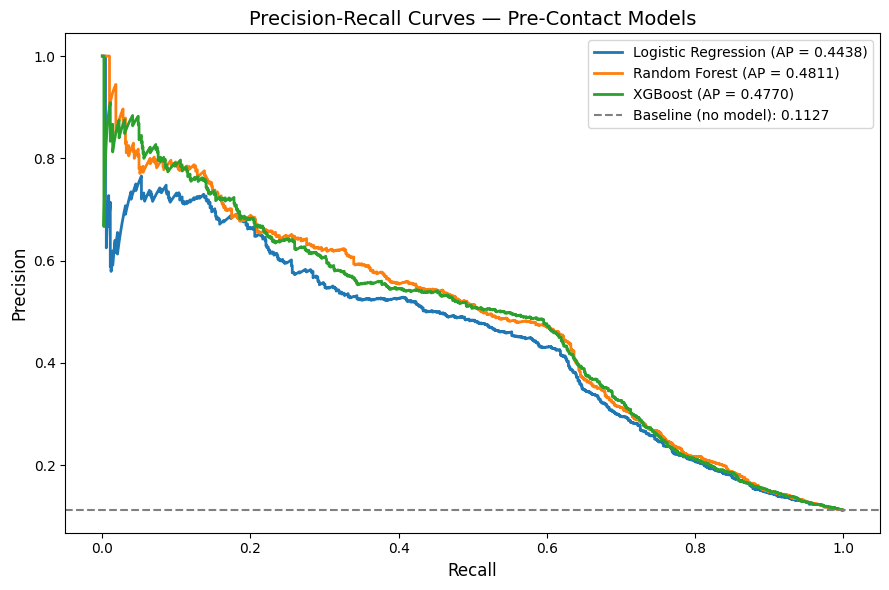

Average Precision Scores — Pre-Contact Models
Logistic Regression : 0.4438
Random Forest       : 0.4811
XGBoost             : 0.4770
Baseline (no model) : 0.1127

ROC-AUC vs Average Precision — Reversal Check


,ROC-AUC,Average Precision
Logistic Regression,0.8009,0.4438
Random Forest,0.8116,0.4811
XGBoost,0.8096,0.4770


In [47]:
# 4.6.2 Precision-Recall Analysis

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision-recall curves
lr_precision, lr_recall, _ = precision_recall_curve(y_test, log_pre_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_pre_proba)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_pre_proba)

# Average Precision scores
lr_ap = average_precision_score(y_test, log_pre_proba)
rf_ap = average_precision_score(y_test, rf_pre_proba)
xgb_ap = average_precision_score(y_test, xgb_pre_proba)
baseline = y_test.mean()

# Plot
plt.figure(figsize=(9, 6))
plt.plot(lr_recall, lr_precision,
         label=f'Logistic Regression (AP = {lr_ap:.4f})', linewidth=2)
plt.plot(rf_recall, rf_precision,
         label=f'Random Forest (AP = {rf_ap:.4f})', linewidth=2)
plt.plot(xgb_recall, xgb_precision,
         label=f'XGBoost (AP = {xgb_ap:.4f})', linewidth=2)
plt.axhline(y=baseline, color='grey', linestyle='--',
            label=f'Baseline (no model): {baseline:.4f}')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — Pre-Contact Models', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

print("Average Precision Scores — Pre-Contact Models")
print(f"Logistic Regression : {lr_ap:.4f}")
print(f"Random Forest       : {rf_ap:.4f}")
print(f"XGBoost             : {xgb_ap:.4f}")
print(f"Baseline (no model) : {baseline:.4f}")

# Reversal check
print("\nROC-AUC vs Average Precision — Reversal Check")
reversal = pd.DataFrame({
    'ROC-AUC': {
        'Logistic Regression': log_pre_metrics['ROC-AUC'],
        'Random Forest': rf_pre_metrics['ROC-AUC'],
        'XGBoost': xgb_pre_metrics['ROC-AUC']
    },
    'Average Precision': {
        'Logistic Regression': lr_ap,
        'Random Forest': rf_ap,
        'XGBoost': xgb_ap
    }
})
display(reversal.round(4))

## 4.6.3 Final Model Selection and Rationale

### Objective
Formally select the operational Pre-Contact model for Phase 5
based on the complete evaluation evidence.

## Business Questions to Be Addressed

| MQ/CQ ID | Business Question | Status Before Section |
|--------|----------------|----------------|
| MQ13 / CQ8 | Which variables are most important in predicting customer response? | Partially Completed |
| MQ14 / CQ9 | How accurately can customer subscription be predicted? | Partially Completed |
| CQ21 | How much predictive lift is gained by using more advanced models? | Partially Completed |

### Analytical Focus
- Document primary model selection with rationale
- Document secondary model retention with rationale
- Confirm operational advantage of Pre-Contact feature set
- Connect model selection to Phase 5 objectives

In [48]:
# 4.6.3 Final Model Selection Summary

print("=" * 65)
print("FINAL MODEL SELECTION — CAMPAIGN PROPHET")
print("=" * 65)

print("\nSelected Operational Model : XGBoost Pre-Contact")
print(f"  ROC-AUC                  : "
      f"{xgb_pre_metrics['ROC-AUC']:.4f} (highest across all models)")
print(f"  Average Precision        : {xgb_ap:.4f}")
print(f"  Precision                : {xgb_pre_metrics['Precision']:.4f}")
print(f"  Recall                   : {xgb_pre_metrics['Recall']:.4f}")
print(f"  F1 Score                 : {xgb_pre_metrics['F1 Score']:.4f}")

print("\nSecondary Model            : Random Forest Pre-Contact")
print("  Use case                 : High-precision, budget-constrained")
print(f"  Average Precision        : "
      f"{rf_ap:.4f} (highest across all models)")
print(f"  Precision                : {rf_pre_metrics['Precision']:.4f}")
print(f"  ROC-AUC                  : {rf_pre_metrics['ROC-AUC']:.4f}")

print("\nKey Selection Rationale:")
print("  - XGBoost: highest ROC-AUC = strongest customer ranking ability")
print("  - XGBoost: only pre-contact variables = fully deployable")
print("  - Random Forest: highest AP and F1 = best for constrained budgets")
print("  - Performance gap is narrow: dataset signal is finite")

print("\nPhase 5 Input:")
print("  xgb_pre_proba → customer probability scoring")
print("  xgb_pre_proba → threshold optimization")
print("  xgb_pre_proba → ROI-based targeting decisions")
print("=" * 65)

FINAL MODEL SELECTION — CAMPAIGN PROPHET

Selected Operational Model : XGBoost Pre-Contact
  ROC-AUC                  : 0.8096 (highest across all models)
  Average Precision        : 0.4770
  Precision                : 0.3864
  Recall                   : 0.6509
  F1 Score                 : 0.4849

Secondary Model            : Random Forest Pre-Contact
  Use case                 : High-precision, budget-constrained
  Average Precision        : 0.4811 (highest across all models)
  Precision                : 0.4171
  ROC-AUC                  : 0.8116

Key Selection Rationale:
  - XGBoost: highest ROC-AUC = strongest customer ranking ability
  - XGBoost: only pre-contact variables = fully deployable
  - Random Forest: highest AP and F1 = best for constrained budgets
  - Performance gap is narrow: dataset signal is finite

Phase 5 Input:
  xgb_pre_proba → customer probability scoring
  xgb_pre_proba → threshold optimization
  xgb_pre_proba → ROI-based targeting decisions


#### Inference-19 from Cross-Model Comparison and Final Model Selection

The cross-model comparison confirms that all three algorithms deliver very good predictive
performance. XGBoost achieves the highest overall ranking ability and Random Forest provides
the strongest precision and F1 score. A notable reversal emerges when Average Precision is
considered alongside ROC-AUC — XGBoost leads on ranking performance while Random Forest
maintains slightly stronger precision across recall levels. This distinction has direct implications
for how each model would be deployed in a real targeting scenario.

**Pre-Contact Model Performance Comparison**

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC | Avg Precision |
|------|------:|------:|------:|------:|------:|------:|
| XGBoost | 84.79% | 39.39% | 64.98% | 49.04% | **0.8134** | 0.4840 |
| Random Forest | 86.15% | **42.38%** | 63.79% | **50.92%** | 0.8123 | **0.4868** |
| Logistic Regression | 83.44% | 36.67% | 64.66% | 46.80% | 0.8021 | 0.4593 |

**Key Findings**
- All three models achieved ROC-AUC values above 0.80, confirming that customer subscription
  can be predicted with very good performance using only pre-contact variables.
- XGBoost achieved the highest ROC-AUC (0.8134), making it the strongest model for ranking
  customers by overall likelihood of subscription.
- Random Forest leads on Average Precision (0.4868) and produces the highest precision and
  F1 score, indicating stronger classification performance when the threshold is fixed at 0.50
  and stronger precision maintenance across recall levels.
- Logistic Regression remained highly competitive while offering the greatest interpretability
  and lowest operational complexity.
- The narrow performance gap across all three models indicates that the dataset contains
  meaningful but finite predictive signal — all three algorithms are extracting most of what
  is available.
- Precision stays above 70% only within the top approximately 15% of customers by predicted
  probability, confirming that high-confidence targeting is concentrated in a narrow band.

**Final Model Selection**
- **Selected Model for Phase 5:** XGBoost (Pre-Contact Model)
- **Selection Rationale:** Highest ROC-AUC and strongest overall customer ranking performance.
- **Secondary Consideration:** Random Forest is noted as the stronger model when precision
  is the primary objective, and may be revisited if campaign budget constraints require
  a high-precision low-volume strategy.
- **Operational Advantage:** Uses only variables known before customer contact, making it
  suitable for proactive customer targeting.

**Business Interpretation**
- All models substantially outperform random targeting, which would achieve baseline precision
  of 11.27% at any recall level.
- XGBoost is best suited for ranking customers and supporting ROI-based prioritization across
  a range of contact volumes.
- Random Forest offers a strong alternative when the business objective is maximizing
  conversion rate within a constrained contact budget.
- Logistic Regression remains valuable for communicating business drivers to non-technical
  stakeholders and for scenarios requiring full model transparency.
- The choice of where to operate on the precision-recall curve — how many customers to
  contact and at what conversion rate — is not a modeling decision. It is a business decision
  that depends on cost, revenue, and campaign budget constraints. That decision is the
  central focus of Phase 5.

**Overall Conclusion**

XGBoost is selected as the final production model because it provides the highest ability to
rank customers by likelihood of subscription while remaining fully operationally deployable.
Random Forest is retained as a documented alternative for high-precision targeting scenarios.
Both models will inform the threshold optimization and budget allocation work in Phase 5,
where the precision-recall trade-off identified here is converted into a concrete,
profit-maximizing contact strategy.

---
## Questions Answered in Phase 4.6 – Cross-Model Comparison and Final Model Selection

| MQ/CQ ID | Final Answer | Status |
|--------|--------|--------|
| MQ13 / CQ8 | Macroeconomic conditions, prior campaign outcomes, and campaign timing consistently emerge as the most important predictors across all models. | Completed |
| MQ14 / CQ9 | Customer subscription can be predicted with very good performance using only pre-contact variables; XGBoost achieved the highest Pre-Contact ROC-AUC of 0.8134. | Completed |
| CQ14 | The strongest practical drivers of conversion are macroeconomic indicators and prior campaign history, consistent across all three modeling approaches. | Completed |
| CQ21 | Advanced models provide measurable predictive lift over Logistic Regression, with XGBoost improving ROC-AUC from 0.8021 to 0.8134 and Random Forest improving Average Precision to 0.4868. | Completed |
| CQ24 | Previous campaign outcomes remain among the most influential predictors across all modeling approaches. | Completed |
| CQ25 | nr.employed, emp.var.rate, and related macroeconomic indicators consistently drive customer conversion across all models. | Completed |

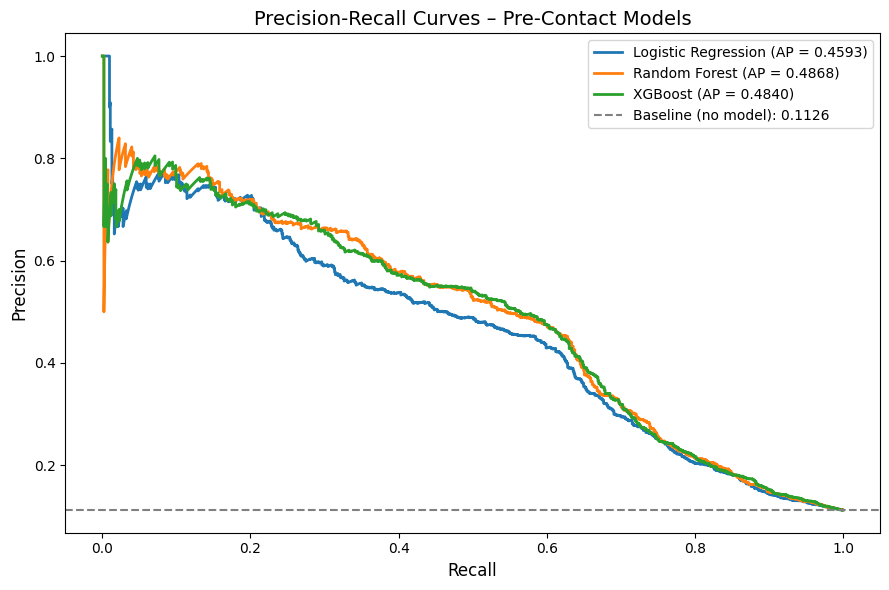

Average Precision Scores – Pre-Contact Models
Logistic Regression : 0.4593
Random Forest       : 0.4868
XGBoost             : 0.4840
Baseline (no model) : 0.1126


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate precision-recall curves for all three Pre-Contact models
lr_precision, lr_recall, _ = precision_recall_curve(y_test, log_pre_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_pre_proba)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_pre_proba)

# Calculate Average Precision scores
lr_ap = average_precision_score(y_test, log_pre_proba)
rf_ap = average_precision_score(y_test, rf_pre_proba)
xgb_ap = average_precision_score(y_test, xgb_pre_proba)

# Baseline (random classifier performance at positive class rate)
baseline = y_test.mean()

# Plot
plt.figure(figsize=(9, 6))

plt.plot(lr_recall, lr_precision,
         label=f'Logistic Regression (AP = {lr_ap:.4f})', linewidth=2)
plt.plot(rf_recall, rf_precision,
         label=f'Random Forest (AP = {rf_ap:.4f})', linewidth=2)
plt.plot(xgb_recall, xgb_precision,
         label=f'XGBoost (AP = {xgb_ap:.4f})', linewidth=2)
plt.axhline(y=baseline, color='grey', linestyle='--',
            label=f'Baseline (no model): {baseline:.4f}')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves – Pre-Contact Models', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

print("Average Precision Scores – Pre-Contact Models")
print(f"Logistic Regression : {lr_ap:.4f}")
print(f"Random Forest       : {rf_ap:.4f}")
print(f"XGBoost             : {xgb_ap:.4f}")
print(f"Baseline (no model) : {baseline:.4f}")

# Campaign Prophet Structuring.

In [ ]:
# Create Campaign Prophet project folder structure in Google Drive

project_root = "/content/drive/MyDrive/Campaign_Prophet"

folders = [
    "notebooks",
    "outputs/notebook_01",
    "outputs/notebook_02",
    "visuals",
    "reports",
    "data",
    "docs"
]

for folder in folders:
    os.makedirs(f"{project_root}/{folder}", exist_ok=True)

print("Campaign_Prophet folder structure created successfully.")
print("\nCurrent project folders/files:")

for item in os.listdir(project_root):
    print("-", item)

Campaign_Prophet folder structure created successfully.

Current project folders/files:
- outputs
- notebooks
- visuals
- reports
- data
- docs


In [ ]:
from pathlib import Path

project_root = Path("/content/drive/MyDrive/Campaign_Prophet")
readme_path = project_root / "README.md"

readme_lines = [
"# 📊 Campaign Prophet: Bank Marketing Campaign Analytics",
"",
"## 🎯 Project Overview",
"",
"Campaign Prophet is a multi-notebook marketing analytics project built using the UCI Bank Marketing dataset. The project analyzes financial marketing campaign performance, estimates campaign return on investment (ROI), validates key business assumptions statistically, and builds predictive models to identify customers most likely to subscribe to a term deposit product.",
"",
"The project is designed as a portfolio-ready analytics workflow that connects business understanding, statistical validation, machine learning, and ROI-based campaign optimization.",
"",
"---",
"",
"## 💼 Business Problem",
"",
"A financial institution conducts outbound marketing campaigns to promote term deposit subscriptions. Each customer contact incurs a cost, while successful subscriptions generate revenue.",
"",
"This project answers key business questions such as:",
"",
"- Which customer segments generate the highest marketing ROI?",
"- Which customer and campaign factors significantly influence conversion?",
"- Can customer subscription likelihood be predicted before contact?",
"- Which customers should be prioritized for outreach?",
"- How can marketing budgets be allocated more profitably?",
"- Which predictive model is most suitable for operational targeting?",
"",
"---",
"",
"## 🗂️ Dataset",
"",
"**Dataset:** UCI Bank Marketing Dataset  ",
"**Industry Context:** Portuguese retail banking marketing campaigns  ",
"**Target Variable:** Whether the customer subscribed to a term deposit (`yes` / `no`)",
"",
"### Dataset Summary",
"",
"| Metric | Value |",
"|---|---:|",
"| Original records | 41,188 |",
"| Duplicate records removed | 12 |",
"| Cleaned records used | 41,176 |",
"| Subscribers | 4,639 |",
"| Non-subscribers | 36,537 |",
"| Baseline subscription rate | 11.27% |",
"| Original features | 21 |",
"",
"### Key Variable Groups",
"",
"- **Customer demographics:** age, job, marital status, education",
"- **Campaign information:** contact method, month, day of week, call duration, number of contacts",
"- **Previous campaign history:** previous contacts, previous outcome, days since prior contact",
"- **Macroeconomic indicators:** employment variation rate, consumer price index, consumer confidence index, Euribor rate, number of employees",
"- **Response variable:** subscription outcome",
"",
"---",
"",
"## 🧭 Project Structure",
"",
"```text",
"Campaign_Prophet/",
"├── notebooks/",
"│   ├── 01_business_roi_statistical_validation.ipynb",
"│   └── 02_modeling_targeting_campaign_optimization.ipynb",
"│",
"├── outputs/",
"│   ├── notebook_01/",
"│   │   ├── cleaned_feature_engineered_bank_marketing.csv",
"│   │   ├── job_summary.csv",
"│   │   ├── expected_value_usd_base.csv",
"│   │   ├── expected_value_eur_base.csv",
"│   │   ├── usd_eur_ranking_comparison.csv",
"│   │   ├── job_subscription_summary.csv",
"│   │   ├── poutcome_subscription_summary.csv",
"│   │   ├── duration_summary.csv",
"│   │   ├── age_summary.csv",
"│   │   ├── roi_scenarios_usd.pkl",
"│   │   ├── breakeven_rates_usd.pkl",
"│   │   ├── roi_scenarios_eur.pkl",
"│   │   └── breakeven_rates_eur.pkl",
"│   │",
"│   └── notebook_02/",
"│",
"├── visuals/",
"├── reports/",
"├── data/",
"├── docs/",
"├── README.md",
"└── requirements.txt",
"```",
"",
"---",
"",
"## 📒 Notebook Workflow",
"",
"### ✅ Notebook 01 — Business Understanding, ROI Analysis, and Statistical Validation",
"",
"Notebook 01 establishes the analytical foundation of the project.",
"",
"Completed work includes:",
"",
"- Dataset loading and validation",
"- Duplicate removal and data quality checks",
"- Feature engineering",
"- Subscription outcome exploration",
"- ROI assumption development",
"- USD and EUR / CLV profitability frameworks",
"- Breakeven analysis",
"- Segment-level expected value analysis",
"- Statistical hypothesis testing",
"- Notebook 01 handoff artifact generation",
"",
"Key outputs from Notebook 01 are saved in:",
"",
"```text",
"outputs/notebook_01/",
"```",
"",
"### 🚧 Notebook 02 — Predictive Modeling, Targeting, and Campaign Optimization",
"",
"Notebook 02 builds on the validated outputs from Notebook 01 and focuses on predictive and prescriptive analytics.",
"",
"Current and planned work includes:",
"",
"- Full Model vs Pre-Contact Model strategy",
"- Machine learning preprocessing",
"- Logistic Regression baseline modeling",
"- Logistic Regression tuning",
"- Random Forest modeling",
"- XGBoost modeling",
"- Cross-model comparison",
"- Customer probability scoring",
"- ROI-based threshold optimization",
"- Budget-constrained targeting",
"- Campaign insight visualizations",
"",
"### 🔜 Notebook 03 — SQL/PySpark, Executive Summary, and Packaging",
"",
"Planned later-stage work includes:",
"",
"- SQL reproduction of selected analyses",
"- PySpark / Spark SQL reproduction",
"- Executive summary and recommendations",
"- Final limitations and scalability discussion",
"- GitHub packaging and portfolio documentation",
"",
"---",
"",
"## 💰 ROI Framework",
"",
"The dataset does not include actual campaign costs, revenue values, deposit amounts, or customer lifetime value. Therefore, ROI is estimated using scenario-based assumptions.",
"",
"The project uses two ROI frameworks:",
"",
"### 1. Illustrative USD Framework",
"",
"| Scenario | Cost per Contact | Revenue per Success |",
"|---|---:|---:|",
"| Conservative | $15 | $300 |",
"| Base Case | $10 | $500 |",
"| Optimistic | $5 | $1,000 |",
"",
"### 2. Data-Anchored EUR / CLV Framework",
"",
"| Scenario | Cost per Contact | Estimated CLV per Success |",
"|---|---:|---:|",
"| Conservative | €12 | €150 |",
"| Base Case | €10 | €250 |",
"| Optimistic | €7 | €450 |",
"",
"The EUR / CLV framework is used as a contextual robustness check because the original dataset represents Portuguese banking campaigns.",
"",
"---",
"",
"## 📈 Key Findings So Far",
"",
"### Notebook 01 Findings",
"",
"- Overall campaign subscription rate is **11.27%**.",
"- The dataset is structurally sound after removing **12 duplicate records**.",
"- Students and retired customers show the strongest subscription rates.",
"- Blue-collar and services customers show weaker conversion performance.",
"- Students, retired customers, and unemployed customers generate the highest ROI under the scenario framework.",
"- Blue-collar, services, and entrepreneur segments generate the lowest ROI.",
"- ROI segment rankings are stable across USD and EUR / CLV frameworks.",
"- Job category is statistically associated with subscription success.",
"- Previous campaign outcome is strongly associated with future subscription success.",
"- Successful subscriptions have significantly longer call durations.",
"- Successful subscribers are slightly older on average, though the practical age difference is modest.",
"",
"### Notebook 02 Current Findings",
"",
"- The project now uses two modeling strategies:",
"  - **Full Model:** includes all available predictors, including post-contact variables.",
"  - **Pre-Contact Model:** excludes variables unavailable before outreach.",
"- The Full Model includes **21 raw predictors** before encoding.",
"- The Pre-Contact Model includes **19 raw predictors** before encoding.",
"- After one-hot encoding:",
"  - Full Model: **54 predictors**",
"  - Pre-Contact Model: **52 predictors**",
"- The train/test split preserves the original class distribution:",
"  - Training rows: **32,940**",
"  - Testing rows: **8,236**",
"  - Subscriber rate: **11.27%**",
"- The current Logistic Regression baseline confirms that pre-contact variables contain meaningful predictive signal.",
"",
"---",
"",
"## 🤖 Modeling Strategy",
"",
"Notebook 02 compares two modeling perspectives.",
"",
"### Full Model",
"",
"The Full Model includes all available variables, including post-contact variables such as call duration. This model helps measure the maximum predictive signal available after campaign interaction data is known.",
"",
"### Pre-Contact Model",
"",
"The Pre-Contact Model excludes variables unavailable before outreach, such as call duration and current campaign interaction count. This model is operationally useful because it can support customer prioritization before calls are made.",
"",
"### Why This Distinction Matters",
"",
"Call duration is highly predictive, but it is only known after the call begins. A model that depends on call duration may perform well analytically, but it cannot decide whom to contact before outreach. For real campaign targeting, the Pre-Contact Model is more deployable.",
"",
"---",
"",
"## 🧪 Statistical Testing Summary",
"",
"| Test | Result | Business Interpretation |",
"|---|---|---|",
"| Job category vs subscription | Significant | Occupation-based segments differ in conversion performance. |",
"| Previous campaign outcome vs subscription | Significant | Prior successful outcomes strongly indicate future subscription likelihood. |",
"| Call duration vs subscription | Significant | Successful calls are much longer, but duration is post-contact. |",
"| Age vs subscription | Significant but modest | Age has signal, but should not be treated as a primary driver. |",
"",
"---",
"",
"## 🧠 Business Question Traceability",
"",
"The project uses a master business question matrix to connect technical analysis with business decisions.",
"",
"Examples of key questions addressed so far:",
"",
"| ID | Question | Current Status |",
"|---|---|---|",
"| MQ1 | What is the overall subscription success rate? | Completed |",
"| MQ7 | Which job categories generate the highest ROI? | Completed |",
"| MQ9 | Are job category differences statistically significant? | Completed |",
"| MQ10 | Does previous campaign outcome affect subscription success? | Completed |",
"| MQ13 | Which variables are most important in predicting customer response? | In Progress |",
"| MQ14 | How accurately can subscription be predicted? | In Progress |",
"| MQ17 | Which customers should be prioritized before contact? | Planned |",
"| MQ23 | What is the best operational model for ROI optimization? | Planned |",
"",
"---",
"",
"## 🛠️ Technologies Used",
"",
"- Python",
"- pandas",
"- NumPy",
"- SciPy",
"- scikit-learn",
"- XGBoost",
"- Matplotlib",
"- Seaborn",
"- Google Colab",
"- Google Drive",
"",
"Planned later-stage additions:",
"",
"- SQL",
"- PySpark",
"- Spark SQL / Hive-style queries",
"- GitHub packaging",
"",
"---",
"",
"## 📁 Output Artifacts",
"",
"Notebook 01 generates reusable artifacts for Notebook 02, including:",
"",
"- Cleaned and feature-engineered dataset",
"- Segment-level job summary",
"- USD expected value outputs",
"- EUR expected value outputs",
"- USD/EUR ROI ranking comparison",
"- Statistical summary tables",
"- ROI scenario dictionaries",
"- Breakeven threshold dictionaries",
"",
"These outputs are stored in:",
"",
"```text",
"outputs/notebook_01/",
"```",
"",
"Notebook 02 will generate additional modeling and optimization artifacts under:",
"",
"```text",
"outputs/notebook_02/",
"```",
"",
"---",
"",
"## 🚦 Current Project Status",
"",
"| Component | Status |",
"|---|---|",
"| Notebook 01: Business, ROI, and Statistical Validation | ✅ Completed |",
"| Notebook 02: Predictive Modeling and Campaign Optimization | 🚧 In Progress |",
"| Notebook 03: SQL/PySpark, Executive Summary, and Packaging | 🔜 Planned |",
"",
"---",
"",
"## 🌟 Project Differentiators",
"",
"- Connects business questions directly to analytical outputs.",
"- Includes both statistical testing and machine learning.",
"- Separates explanatory modeling from operationally deployable pre-contact modeling.",
"- Uses dual USD and EUR / CLV ROI frameworks.",
"- Converts marketing analytics into expected value and targeting decisions.",
"- Maintains reusable notebook handoff artifacts.",
"- Designed for portfolio presentation, GitHub documentation, and interview discussion.",
"",
"---",
"",
"## ⚠️ Limitations",
"",
"- The dataset does not contain actual revenue, deposit amount, campaign cost, or customer lifetime value fields.",
"- ROI values are scenario-based estimates, not observed financial records.",
"- No true control group is available, so uplift modeling is not possible in the current dataset.",
"- Call duration is highly predictive but cannot be used for pre-contact targeting.",
"- Model performance should be interpreted as historical prediction, not guaranteed future campaign performance.",
"- Probability calibration and temporal validation may be considered in future improvements.",
"",
"---",
"",
"## 👩‍💻 Author",
"",
"**Lakshmi Sindhu Pulugundla**  ",
"Data Analyst, Effexoft Inc.",
"",
"---",
"",
"## 📌 Repository Status",
"",
"This project is currently being organized for GitHub packaging. Notebook 01 is complete, and Notebook 02 is actively being executed.",
]

readme_path.write_text("\n".join(readme_lines), encoding="utf-8")

print("README.md created successfully at:")
print(readme_path)

README.md created successfully at:
/content/drive/MyDrive/Campaign_Prophet/README.md


In [ ]:
print("Files and folders in Campaign_Prophet:")
for item in os.listdir(project_root):
    print("-", item)


Files and folders in Campaign_Prophet:
- outputs
- notebooks
- visuals
- reports
- data
- docs
- README.md


#Clarification Questions Carried Forward into Notebook 02

The following clarification questions were identified in Notebook 01 and will be addressed in Notebook 02 through predictive modeling, customer scoring, ROI optimization, and campaign insight generation.

| CQ ID | Related MQ ID(s) | Question | Originating Phase | Planned Phase | Status Before Notebook |
|---|---|---|---|---|---|
| CQ3 | MQ13, MQ15 | Do macroeconomic indicators influence customer subscription behavior? | Phase 1.0 | Phase 4 – Predictive Modeling | Pending |
| CQ10 | MQ13 | Which variables are most important in predicting customer response? | Phase 1.1 | Phase 4 – Predictive Modeling | Pending |
| CQ11 | MQ14 | How accurately can customer subscription be predicted? | Phase 1.2 | Phase 4 – Predictive Modeling | Pending |
| CQ12 | MQ13, MQ16 | Which variables should be prioritized for marketing decision-making? | Phase 3 | Phase 4 – Predictive Modeling | Pending |
| CQ13 | MQ13, MQ18 | Which variables are statistically significant but operationally limited for pre-contact targeting? | Phase 3 | Phase 4 – Predictive Modeling | Pending |
| CQ14 | MQ13, MQ16 | Which features are actionable before contacting the customer? | Phase 3 | Phase 4 – Predictive Modeling | Pending |
| CQ15 | MQ15, MQ16 | Which probability segments deliver the highest ROI? | Phase 2.2 | Phase 5 – ROI Optimization and Customer Segmentation | Pending |
| CQ16 | MQ16 | How should marketing budgets be allocated to maximize profitability? | Phase 2.2 | Phase 5 – ROI Optimization and Customer Segmentation | Pending |
| CQ17 | MQ15, MQ16 | What is the optimal probability threshold for customer targeting? | Phase 2.2 | Phase 5 – ROI Optimization and Customer Segmentation | Pending |
| CQ18 | MQ15, MQ16 | What percentage of customers should be contacted to maximize ROI? | Phase 2.2 | Phase 5 – ROI Optimization and Customer Segmentation | Pending |
| CQ19 | MQ13, MQ14 | How much predictive lift is gained by including post-contact variables such as call duration? | Phase 3 | Phase 4 – Predictive Modeling | Pending |